In [1]:
import numpy as np
import pandas as pd 
import cv2
import matplotlib.pyplot as plt
import easyocr
import pymc as pm 
import arviz as az
reader = easyocr.Reader(['en'], gpu=False)
np.random.seed(42)

Using CPU. Note: This module is much faster with a GPU.


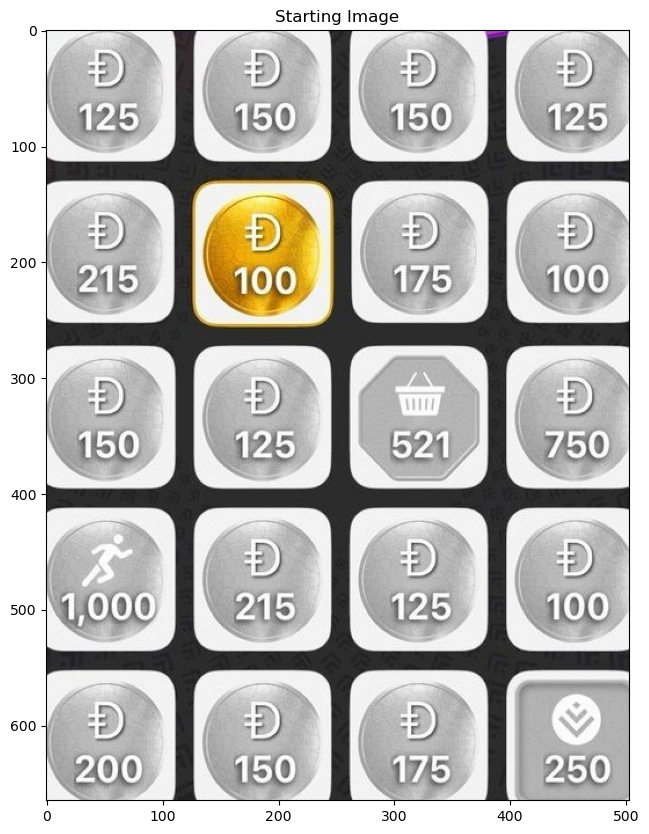

In [2]:
path = '../data/images/Images4.jpeg'
img = cv2.imread(path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(10,10))
plt.imshow(img_rgb)
plt.title("Starting Image")
plt.show()

In [3]:
#test_tile = img_rgb[1:150, 50:150]
#plt.imshow(test_tile)
#plt.show

In [4]:
#test_tile2 = img_rgb[150:275, 180:280]
#plt.imshow(test_tile2)
#plt.show

In [5]:
height, width, _ = img_rgb.shape
rows = 5 
cols = 4

## split image intp 5 by 4 grid - requires cropped screenshot to be uploaded 
row_step = height / rows 
col_step = width / cols
numbers = []
for r in range(rows):
    for c in range(cols):
        y1, y2 = r * row_step, (r +1) * row_step
        x1, x2 = c * col_step, (c +1) * col_step

        tile = img_rgb[int(y1):int(y2), int(x1):int(x2)]
        ## exract bottom part with number
        t_h, t_w, _ = tile.shape
        number = tile[int(t_h * 0.5):t_h, 0:t_w]
        numbers.append(number)
        #plt.imshow(number)
        #plt.show()
        

        

In [6]:
def number_extractor(image):
    gray_tile = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    _, thresh = cv2.threshold(gray_tile, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    padding = 15
    padded_tile = cv2.copyMakeBorder(
        thresh, 
        padding, padding, padding, padding, 
        cv2.BORDER_CONSTANT, 
        value=[255, 255, 255]
    )
    upscaled = cv2.resize(padded_tile, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC)
    results = reader.readtext(upscaled)
    if not results:
        return None 
    text = results[0][1]
    clean = ''.join(filter(str.isdigit, text))
    return int(clean) if clean else None

vals=[]
for i in range(20):
    value = number_extractor(numbers[i])
    vals.append(value)
    print(f'OCR got {value}')



C:\Users\ethan\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


OCR got 122
OCR got None
OCR got 50
OCR got None
OCR got 216
OCR got 700
OCR got None
OCR got 12
OCR got 1600
OCR got 12
OCR got None
OCR got 1
OCR got None
OCR got 216
OCR got 1265
OCR got 100
OCR got 20
OCR got 160
OCR got 1745
OCR got 251


In [7]:
import sys
import os
sys.path.append(os.path.abspath('..')) 

from src.database import save_results


In [8]:
#board_values = vals 

# Path to the image you just processed
#image_path = "../data/raw_images/test_board.png"

#clean_values = np.ascontiguousarray(board_values).tolist()

# Now pass the clean version
#try:
   # board_id = save_results(clean_values, image_path)
   # print(f"Successfully populated database! Board ID: {board_id}")
#except Exception as e:
 #   print(f"Database save failed: {e}")

In [9]:
imgs = []
for k in range(12):
    # Double check this file naming convention!
    path = f'../data/images/Images{k+1}.jpeg' 
    img = cv2.imread(path)
    
    # Prevent cvtColor from crashing if the file is missing
    if img is None:
        print(f"Warning: Could not read image at {path}. Skipping...")
        continue
        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    height, width, _ = img_rgb.shape
    rows = 5 
    cols = 4
    
    row_step = height / rows 
    col_step = width / cols
    numbers = []
    
    for r in range(rows):
        for c in range(cols):
            y1, y2 = r * row_step, (r + 1) * row_step
            x1, x2 = c * col_step, (c + 1) * col_step
    
            tile = img_rgb[int(y1):int(y2), int(x1):int(x2)]
            
            # Extract bottom half with number
            t_h, t_w, _ = tile.shape
            number = tile[int(t_h * 0.5):t_h, 0:t_w]
            numbers.append(number)
            
    # 2. INDENTATION: Ensure this is outside the grid loops
    vals = [] 
    
    for i in range(20):
        # Assuming number_extractor is a custom OCR function you defined elsewhere
        value = number_extractor(numbers[i])
        vals.append(value)
        print(f'Board {k+1}, Tile {i+1}: OCR got {value}')
        
    # 3. SYNTAX FIX: Parentheses, not square brackets
    imgs.append(vals) 

# Final output
print(f"Successfully processed {len(imgs)} boards.")

Board 1, Tile 1: OCR got 175
Board 1, Tile 2: OCR got 150
Board 1, Tile 3: OCR got 150
Board 1, Tile 4: OCR got 150
Board 1, Tile 5: OCR got 200
Board 1, Tile 6: OCR got 150
Board 1, Tile 7: OCR got 200
Board 1, Tile 8: OCR got 220
Board 1, Tile 9: OCR got 150
Board 1, Tile 10: OCR got 150
Board 1, Tile 11: OCR got 210
Board 1, Tile 12: OCR got 215
Board 1, Tile 13: OCR got 150
Board 1, Tile 14: OCR got 150
Board 1, Tile 15: OCR got 200
Board 1, Tile 16: OCR got 500
Board 1, Tile 17: OCR got 175
Board 1, Tile 18: OCR got 300
Board 1, Tile 19: OCR got 500
Board 1, Tile 20: OCR got 175
Board 2, Tile 1: OCR got 340
Board 2, Tile 2: OCR got 200
Board 2, Tile 3: OCR got 150
Board 2, Tile 4: OCR got 1000
Board 2, Tile 5: OCR got 344
Board 2, Tile 6: OCR got 1000
Board 2, Tile 7: OCR got 150
Board 2, Tile 8: OCR got 150
Board 2, Tile 9: OCR got 250
Board 2, Tile 10: OCR got 250
Board 2, Tile 11: OCR got 150
Board 2, Tile 12: OCR got 175
Board 2, Tile 13: OCR got 150
Board 2, Tile 14: OCR got 

In [10]:
# manually fic issues with board 4 OCR
imgs[8][10] = 1450
imgs[3][1] = 150
imgs[3][2] = 150
imgs[3][3] = 125
imgs[3][4] = 215
imgs[3][5] = 100
imgs[3][6] = 175
imgs[3][7] = 100
imgs[3][8] = 150
imgs[3][9] = 125
imgs[3][10] = 521
imgs[3][11] = 750
imgs[3][12] = 1000
imgs[3][13] = 215
imgs[3][14] = 125
imgs[3][15] = 100
imgs[3][16] = 200
imgs[3][17] = 150
imgs[3][18] = 175
imgs[3][19] = 250
imgs[3][0] = 125

In [11]:
records = []
for board_index, board_values in enumerate(imgs):
   # preserve user0
    current_user_id = board_index + 1 
    
    for sq_index, reward in enumerate(board_values):
        records.append({
            'grid_index': sq_index,     
            'reward_amount': reward,
            'user_idx': current_user_id
        })

# Create the DataFrame
internet_df = pd.DataFrame(records)

# If the OCR grabbed a letter by mistake
internet_df['reward_amount'] = pd.to_numeric(internet_df['reward_amount'], errors='coerce')

(array([ 0.,  0., 45., 96., 32., 13.,  5.,  4.,  1.,  0.,  8.,  1.,  4.,
         0.,  2., 12.,  0.,  0.,  1.,  0., 10.,  0.,  0.,  0.,  1.,  1.,
         0.,  1.,  2.]),
 array([   0.,   50.,  100.,  150.,  200.,  250.,  300.,  350.,  400.,
         450.,  500.,  550.,  600.,  650.,  700.,  750.,  800.,  850.,
         900.,  950., 1000., 1050., 1100., 1150., 1200., 1250., 1300.,
        1350., 1400., 1450.]),
 <BarContainer object of 29 artists>)

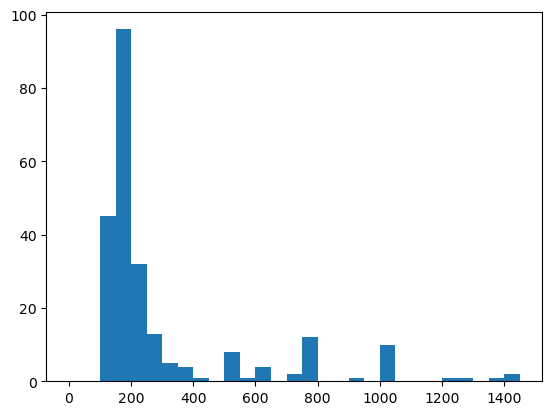

In [12]:
bins = np.arange(0, 1500, 50)
plt.hist(internet_df.reward_amount, bins=bins)

In [13]:
from src.database import get_history_df
df = get_history_df()

(array([ 0.,  0., 17., 38., 10.,  1.,  0.,  4.,  3.,  0.,  3.,  0.,  0.,
         0.,  0.,  2.,  0.,  0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.]),
 array([   0.,   50.,  100.,  150.,  200.,  250.,  300.,  350.,  400.,
         450.,  500.,  550.,  600.,  650.,  700.,  750.,  800.,  850.,
         900.,  950., 1000., 1050., 1100., 1150., 1200., 1250., 1300.,
        1350., 1400., 1450.]),
 <BarContainer object of 29 artists>)

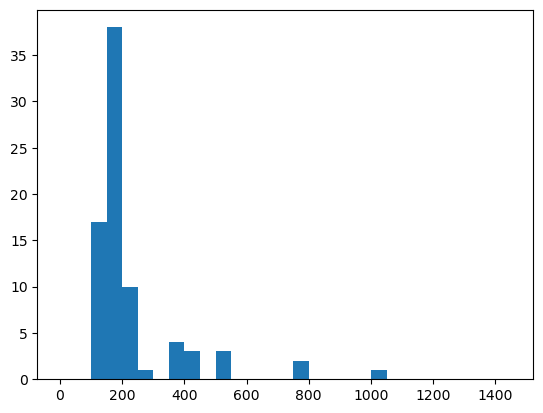

In [14]:
plt.hist(df.reward_amount, bins=bins)

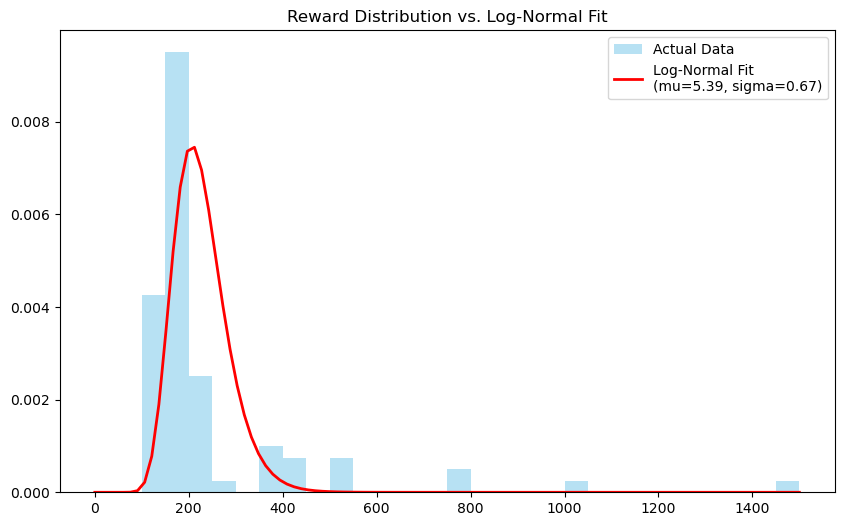

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

# 1. Fit the Log-Normal parameters
shape, loc, scale = lognorm.fit(internet_df['reward_amount'], floc=0) # We lock loc to 0 for money

# 2. Create the X-axis
x = np.linspace(0, internet_df['reward_amount'].max(), 100)
pdf = lognorm.pdf(x, 0.25, loc, scale)

# 3. Plot
plt.figure(figsize=(10, 6))
plt.hist(df['reward_amount'], bins=np.arange(0, df['reward_amount'].max() + 50, 50), 
         density=True, alpha=0.6, color='skyblue', label='Actual Data')
plt.plot(x, pdf, 'r-', lw=2, label=f'Log-Normal Fit\n(mu={np.log(scale):.2f}, sigma={shape:.2f})')

plt.title("Reward Distribution vs. Log-Normal Fit")
plt.legend()
plt.show()

In [16]:
df['user_idx'] = 0
df = df.drop(axis=1, labels=['board_id','id'])

In [17]:
dft = pd.concat([df, internet_df], ignore_index=True)

In [18]:
user_idx=dft['user_idx'].values.astype(int)
sq_idx=dft['grid_index'].values.astype(int)
rewards=dft['reward_amount'].values
n_u = dft['user_idx'].nunique()
n_sq = 20
with pm.Model() as model_3L:
    ## level 3 
    mu_global = pm.Normal('mu_global', mu=5.39, sigma=0.67)
    ## level 2 - squares 
    tau_sq = pm.HalfNormal('tau_sq', sigma=1)
    sq_offset = pm.Normal("sq_offset", mu=0, sigma=1, shape=n_sq)
    sq_effect = pm.Deterministic('sq_effect', sq_offset* tau_sq)

    ## level 2 user 
    tau_u = pm.HalfNormal('tau_u', sigma=1)
    u_offset = pm.Normal('u_offset', mu=0, sigma=1, shape=n_u)
    u_effect = pm.Deterministic('u_effect', u_offset * tau_u)
    ## Level 1
    mu_final = mu_global + sq_effect[sq_idx] + u_effect[user_idx]
    sigma_y = pm.HalfNormal('sigma_y', sigma=1)

    y_obs = pm.LogNormal('y_obs',mu=mu_final, sigma=sigma_y,
                        observed=rewards)
    trace=pm.sample(10000, tune=2000, target_accept=0.95, return_inferencedata=True, random_seed=42)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu_global, tau_sq, sq_offset, tau_u, u_offset, sigma_y]


Output()

Sampling 4 chains for 2_000 tune and 10_000 draw iterations (8_000 + 40_000 draws total) took 228 seconds.


In [19]:

# 1. Get a summary of the key variables
summary = az.summary(trace, var_names=["mu_global", "tau_sq", "tau_u", "sq_effect"])

# 2. View the table (The last column is r_hat)
print(summary[["mean", "sd", "r_hat"]])

                mean     sd  r_hat
mu_global      5.364  0.047    1.0
tau_sq         0.061  0.044    1.0
tau_u          0.063  0.045    1.0
sq_effect[0]  -0.039  0.073    1.0
sq_effect[1]   0.024  0.066    1.0
sq_effect[2]  -0.004  0.062    1.0
sq_effect[3]  -0.015  0.064    1.0
sq_effect[4]  -0.007  0.063    1.0
sq_effect[5]   0.003  0.062    1.0
sq_effect[6]  -0.020  0.065    1.0
sq_effect[7]  -0.026  0.068    1.0
sq_effect[8]  -0.012  0.063    1.0
sq_effect[9]   0.027  0.068    1.0
sq_effect[10]  0.021  0.065    1.0
sq_effect[11] -0.001  0.062    1.0
sq_effect[12]  0.016  0.065    1.0
sq_effect[13]  0.001  0.063    1.0
sq_effect[14]  0.008  0.063    1.0
sq_effect[15] -0.020  0.066    1.0
sq_effect[16]  0.027  0.068    1.0
sq_effect[17]  0.029  0.068    1.0
sq_effect[18]  0.026  0.067    1.0
sq_effect[19] -0.040  0.073    1.0


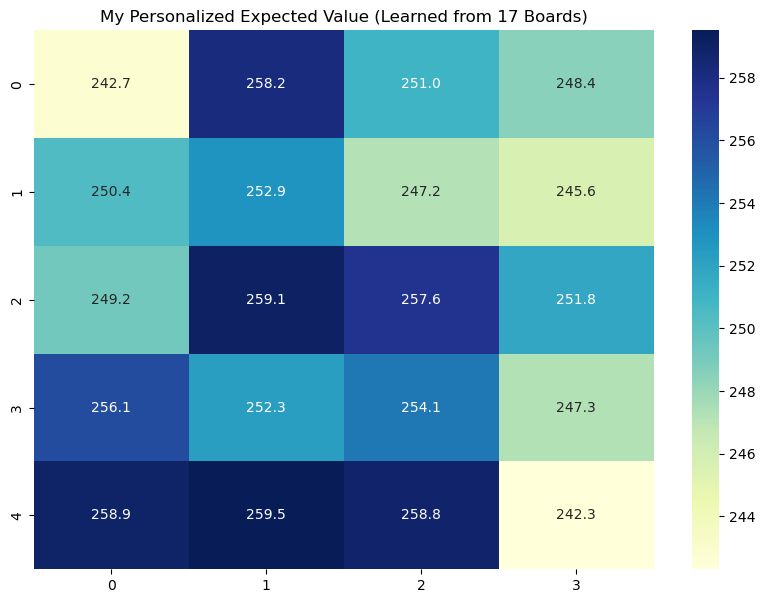

In [25]:
# Extract the posterior samples
posterior = trace.posterior
mu_g = posterior["mu_global"].values          # Shape: (chains, draws)
sq_eff = posterior["sq_effect"].values    # Shape: (chains, draws, 20)
usr_eff = posterior["u_effect"].values     # Shape: (chains, draws, n_users)
sigma_y = posterior["sigma_y"].values         # Shape: (chains, draws)

#slice usr_eff[:, :, 0] to only grab User 0
my_mu_log = mu_g[..., None] + sq_eff + usr_eff[:, :, 0][..., None]

# Convert from log-space to real Currency Expected Value (EV)
# EV of Log-Normal = exp(mu + sigma^2 / 2)
my_ev_samples = np.exp(my_mu_log + (sigma_y[..., None]**2) / 2)

#Get the mean EV across all chains/draws for each of the 20 squares
my_final_board_ev = my_ev_samples.mean(axis=(0, 1))

#  Plot the final heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(my_final_board_ev.reshape(5, 4), annot=True, fmt=".1f", cmap="YlGnBu")
plt.title("My Personalized Expected Value (Learned from 17 Boards)")
plt.show()

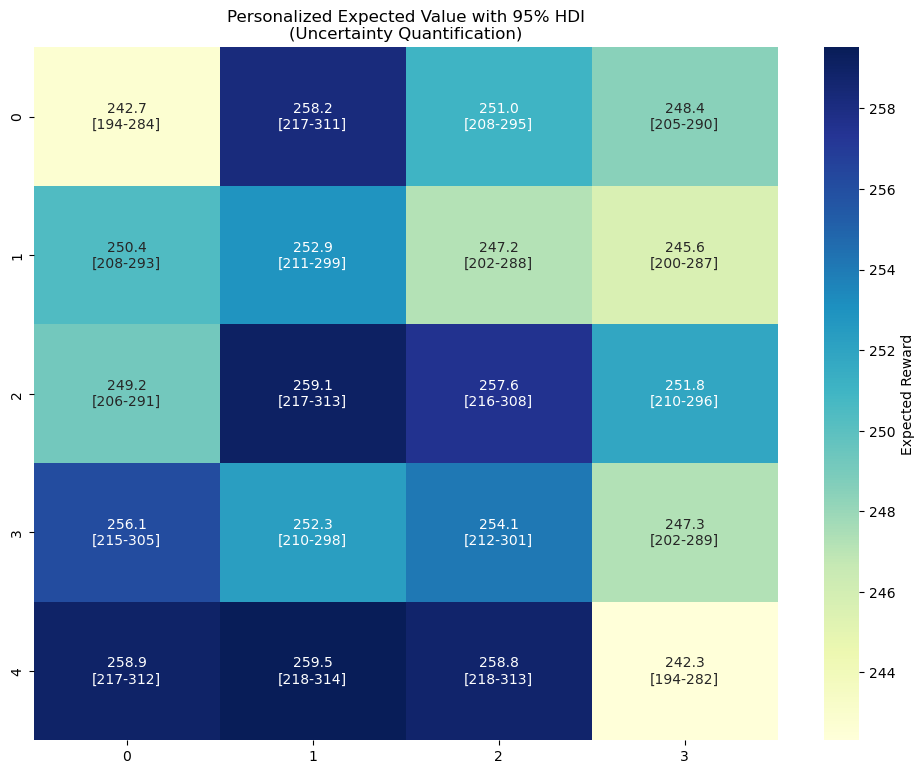

In [27]:
# 1. Calculate HDI bounds (2.5% and 97.5% quantiles)
# my_ev_samples shape is (chains, draws, 20)
hdi_lower = np.percentile(my_ev_samples, 2.5, axis=(0, 1))
hdi_upper = np.percentile(my_ev_samples, 97.5, axis=(0, 1))

# 2. Create custom annotation strings: "Mean \n [Lower - Upper]"
annot_matrix = []
for m, l, u in zip(my_final_board_ev, hdi_lower, hdi_upper):
    annot_matrix.append(f"{m:.1f}\n[{l:.0f}-{u:.0f}]")

# Reshape back to the 5x4 grid
annot_matrix = np.array(annot_matrix).reshape(5, 4)
display_grid = my_final_board_ev.reshape(5, 4)

# 3. Plot
plt.figure(figsize=(12, 9))
sns.heatmap(display_grid, 
            annot=annot_matrix, 
            fmt="", 
            cmap="YlGnBu", 
            cbar_kws={'label': 'Expected Reward'})

plt.title("Personalized Expected Value with 95% HDI\n(Uncertainty Quantification)")
plt.show()

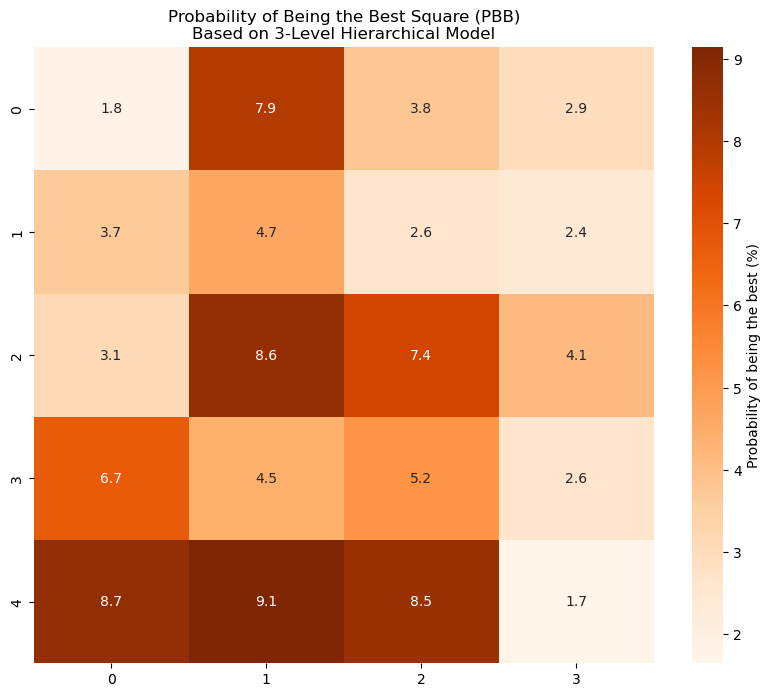

In [29]:
ev_flat = my_ev_samples.reshape(-1, 20)

# For each sample, find the index of the square with the max EV
winners = np.argmax(ev_flat, axis=1)

# Calculate the percentage of 'wins' for each of the 20 squares
pbb_counts = np.bincount(winners, minlength=20)
pbb_percentage = (pbb_counts / len(winners)) * 100

# Reshape and Plot
pbb_grid = pbb_percentage.reshape(5, 4)

plt.figure(figsize=(10, 8))
sns.heatmap(pbb_grid, 
            annot=True, 
            fmt=".1f", 
            cmap="Oranges", 
            cbar_kws={'label': 'Probability of being the best (%)'})

plt.title("Probability of Being the Best Square (PBB)\nBased on 3-Level Hierarchical Model")
plt.show()